# Effects of Preprocessing on NLP Classification Performance

**Research question:** How do different text-preprocessing strategies affect sentiment-classification performance on TweetEval?

**Hypothesis (H1):** Preprocessing that removes irrelevant linguistic noise while retaining sentiment-bearing information will improve Macro-F1 compared with the unprocessed tweet text.

**Experimental control:** The dataset split, TF-IDF settings, Logistic Regression classifier and evaluation metrics remain fixed. Only preprocessing changes.

In [1]:
# Install once if required:
# %pip install -q datasets scikit-learn pandas numpy matplotlib seaborn nltk

import re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

SEED = 42
random.seed(SEED); np.random.seed(SEED)
nltk.download("stopwords", quiet=True)

LABELS = ["negative", "neutral", "positive"]
STOPWORDS = set(stopwords.words("english"))
STEMMER = SnowballStemmer("english")


## 1. Load the existing TweetEval sentiment dataset

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 45,615 | Test: 12,284
label
negative     7093
neutral     20673
positive    17849
Name: count, dtype: int64


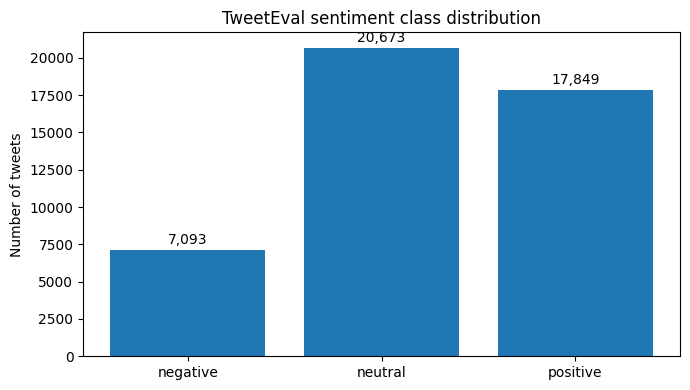

In [2]:
data = load_dataset("cardiffnlp/tweet_eval", "sentiment")
train = data["train"].to_pandas()
test = data["test"].to_pandas()

print(f"Train: {len(train):,} | Test: {len(test):,}")
print(train["label"].value_counts().sort_index().rename(index=dict(enumerate(LABELS))))

# Dataset class distribution
counts = train["label"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(LABELS, counts.values)
plt.ylabel("Number of tweets")
plt.title("TweetEval sentiment class distribution")
for i, v in enumerate(counts.values):
    plt.text(i, v + 400, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig("01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 2. Four controlled preprocessing strategies

In [3]:
def raw_text(text):
    return text

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    return re.sub(r"\s+", " ", text).strip()

def stopword_text(text):
    tokens = re.findall(r"(?u)\b\w[\w']*\b", normalize_text(text))
    return " ".join(t for t in tokens if t not in STOPWORDS)

def stem_text(text):
    return " ".join(STEMMER.stem(t) for t in stopword_text(text).split())

PREPROCESSORS = {
    "Raw": raw_text,
    "Normalised": normalize_text,
    "Stopword removed": stopword_text,
    "Stemmed": stem_text
}

display(pd.DataFrame({
    name: train["text"].head(3).map(func) for name, func in PREPROCESSORS.items()
}))


,Raw,Normalised,Stopword removed,Stemmed
0,"""QT @user In the original draft of the 7th boo...","""qt USER in the original draft of the 7th book...",qt USER original draft 7th book remus lupin su...,qt user origin draft 7th book remus lupin surv...
1,"""Ben Smith / Smith (concussion) remains out of...","""ben smith / smith (concussion) remains out of...",ben smith smith concussion remains lineup thur...,ben smith smith concuss remain lineup thursday...
2,Sorry bout the stream last night I crashed out...,sorry bout the stream last night i crashed out...,sorry bout stream last night crashed tonight s...,sorri bout stream last night crash tonight sur...


## 3. Train identical TF-IDF + Logistic Regression models

In [4]:
def build_model():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=False, ngram_range=(1,2),
            min_df=2, max_features=100000, sublinear_tf=True
        )),
        ("clf", LogisticRegression(C=1.0, max_iter=1500, random_state=SEED))
    ])

results, predictions = [], {}

for name, func in PREPROCESSORS.items():
    model = build_model()
    model.fit(train["text"].map(func), train["label"])
    pred = model.predict(test["text"].map(func))
    predictions[name] = pred

    results.append({
        "Preprocessing": name,
        "Accuracy": accuracy_score(test["label"], pred),
        "Macro-F1": f1_score(test["label"], pred, average="macro"),
        "Negative F1": f1_score(test["label"], pred, labels=[0], average="macro"),
        "Neutral F1": f1_score(test["label"], pred, labels=[1], average="macro"),
        "Positive F1": f1_score(test["label"], pred, labels=[2], average="macro")
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))


,Preprocessing,Accuracy,Macro-F1,Negative F1,Neutral F1,Positive F1
0,Raw,0.5775,0.5360,0.3976,0.6608,0.5496
1,Normalised,0.5906,0.5548,0.4316,0.6657,0.5669
2,Stopword removed,0.5803,0.5414,0.4206,0.6585,0.5451
3,Stemmed,0.5988,0.5687,0.4830,0.6660,0.5571


## 4. Main visualisation — preprocessing effect

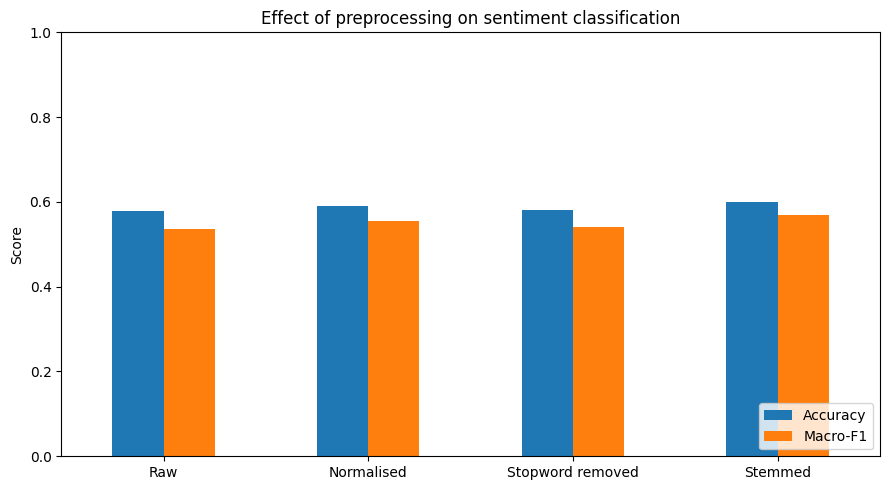

In [5]:
ax = results_df.set_index("Preprocessing")[["Accuracy","Macro-F1"]].plot(
    kind="bar", figsize=(9,5)
)
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_title("Effect of preprocessing on sentiment classification")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("02_preprocessing_performance.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Class-level F1

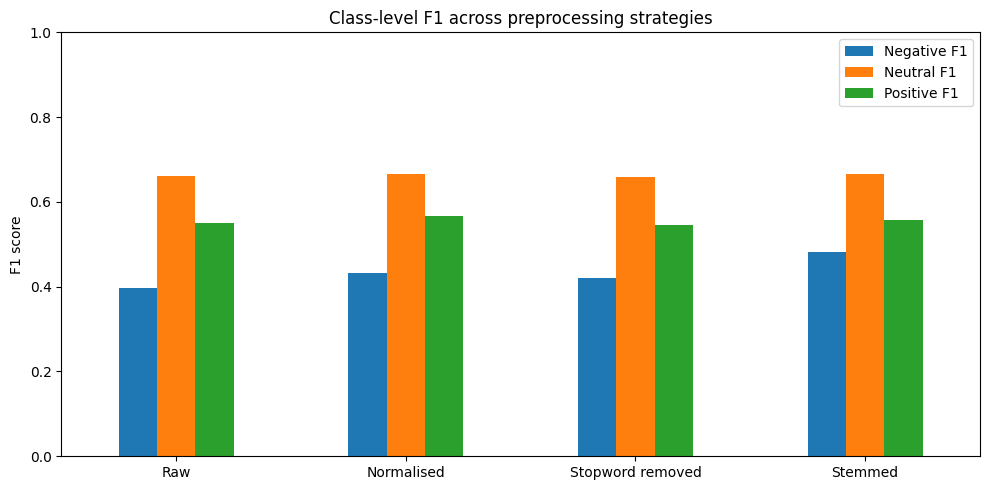

In [6]:
ax = results_df.set_index("Preprocessing")[
    ["Negative F1","Neutral F1","Positive F1"]
].plot(kind="bar", figsize=(10,5))
ax.set_ylim(0,1)
ax.set_ylabel("F1 score")
ax.set_xlabel("")
ax.set_title("Class-level F1 across preprocessing strategies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("03_class_level_f1.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Change in Macro-F1 relative to raw text

,Preprocessing,Macro-F1,Macro-F1 change
0,Raw,0.5360,0.0000
1,Normalised,0.5548,0.0188
2,Stopword removed,0.5414,0.0054
3,Stemmed,0.5687,0.0327


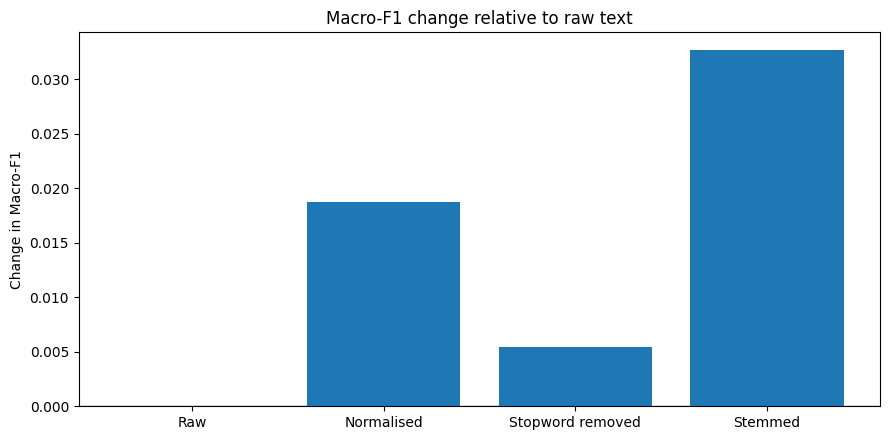

In [7]:
raw_f1 = results_df.loc[
    results_df["Preprocessing"]=="Raw", "Macro-F1"
].iloc[0]
delta = results_df.copy()
delta["Macro-F1 change"] = delta["Macro-F1"] - raw_f1

display(delta[["Preprocessing","Macro-F1","Macro-F1 change"]].round(4))

plt.figure(figsize=(9,4.5))
plt.bar(delta["Preprocessing"], delta["Macro-F1 change"])
plt.axhline(0, linewidth=1)
plt.ylabel("Change in Macro-F1")
plt.title("Macro-F1 change relative to raw text")
plt.tight_layout()
plt.savefig("04_macro_f1_change.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Confusion matrix for the best preprocessing strategy

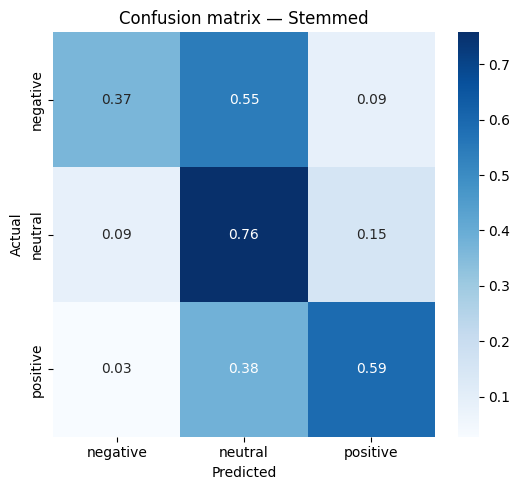

Best preprocessing: Stemmed
Best Macro-F1: 0.5687
Raw Macro-F1: 0.5360
Change: +0.0327


In [8]:
best_name = results_df.loc[results_df["Macro-F1"].idxmax(), "Preprocessing"]
pred = predictions[best_name]

cm = confusion_matrix(test["label"], pred, labels=[0,1,2])
cm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5.5,5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title(f"Confusion matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("05_best_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Best preprocessing: {best_name}")
print(f"Best Macro-F1: {results_df['Macro-F1'].max():.4f}")
print(f"Raw Macro-F1: {raw_f1:.4f}")
print(f"Change: {results_df['Macro-F1'].max()-raw_f1:+.4f}")
